# Proyek Klasifikasi Gambar: CIFAR-10
- **Nama:** Nikola Izzan Ar Rasheed
- **Email:** izzannikola@student.ub.ac.id
- **ID Dicoding:** nikolaizzan

## Import Semua Packages/Library yang Digunakan

In [43]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

## Data Preparation

### Data Loading

In [44]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

### Data Preprocessing

#### Split Dataset

In [45]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=123
)

In [46]:
print(f"Train samples: {x_train.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")

Train samples: 40000
Validation samples: 10000
Test samples: 10000


In [47]:
# List nama kelas CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print(f"Jumlah kelas: {len(class_names)}")
print("Daftar kelas:")
for idx, name in enumerate(class_names):
    print(f"{idx}: {name}")

Jumlah kelas: 10
Daftar kelas:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


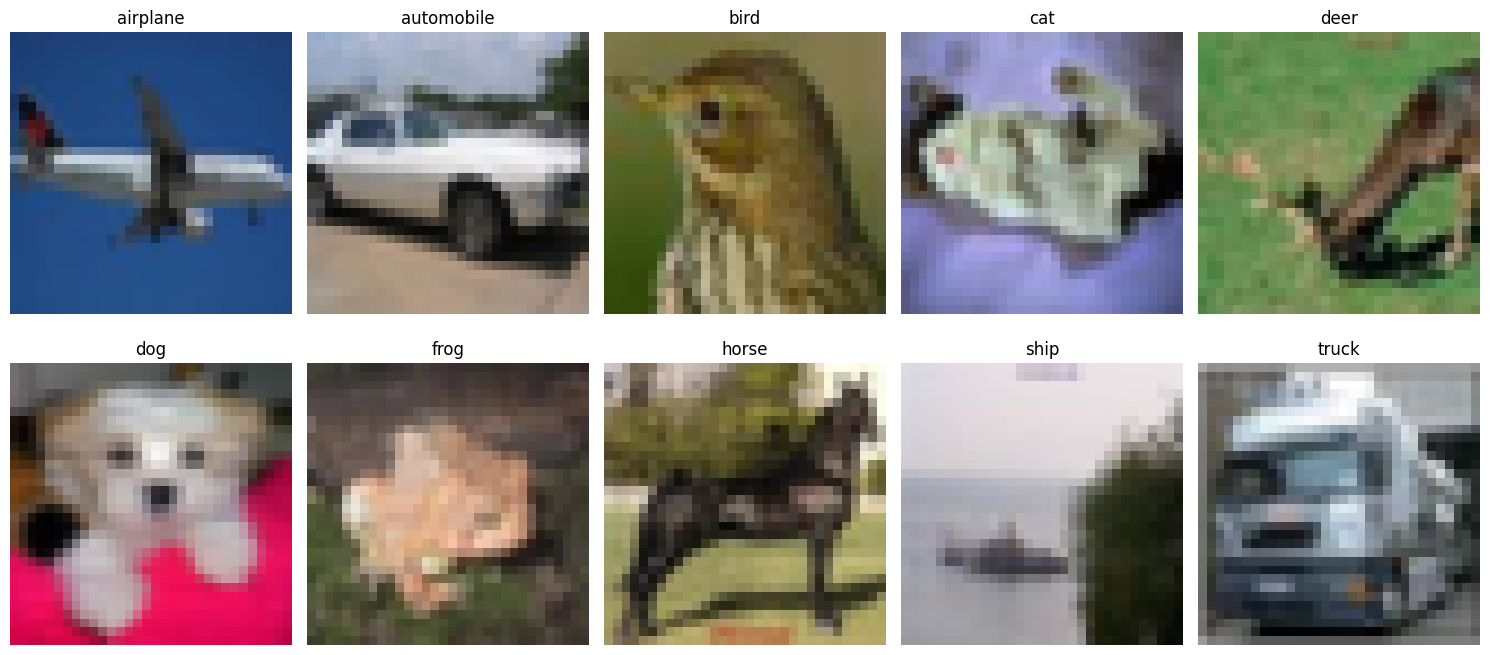

In [48]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))  # 2 rows, 5 columns

for i in range(10):
    ax = axes[i // 5, i % 5]

    # Ambil gambar dari data CIFAR-10
    img = x_train[y_train.flatten() == i][0]  # Ambil gambar pertama dari kelas i
    ax.imshow(img)
    ax.set_title(class_names[i])
    ax.axis('off')  # Matikan axis

plt.tight_layout()
plt.show()

In [49]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

def preprocess(x, y):
    x = tf.image.resize(x, IMG_SIZE)
    x = preprocess_input(x)
    return x, y

In [50]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [51]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

## Modelling

In [52]:
# Modelling
num_classes = 10

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    layers.Lambda(preprocess_input),
    base_model,

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 2, 2, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 2, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 1, 1, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,655,146 (10.13 MB)

 Trainable params: 396,970 (1.51 MB)

 Non-trainable params: 2,258,176 (8.61 MB)

In [54]:
# Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2749 - loss: 2.0300

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 39ms/step - accuracy: 0.2750 - loss: 2.0299 - val_accuracy: 0.1621 - val_loss: 4.0754
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4119 - loss: 1.6429

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.4119 - loss: 1.6429 - val_accuracy: 0.3797 - val_loss: 1.7101
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.4467 - loss: 1.5474 - val_accuracy: 0.2005 - val_loss: 3.0191
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.4612 - loss: 1.5117 - val_accuracy: 0.3407 - val_loss: 1.8728
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 77s 35ms/step - accuracy: 0.4824 - loss: 1.4654 - val_accuracy: 0.2762 - val_loss: 3.0349
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.4904 - loss: 1.4359 - val_accuracy: 0.2112 - val_loss: 2.7134
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.5006 - loss: 1.4123 - val_accuracy: 0.2512 - val_loss: 3.1228
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.5064 - loss: 1.3984 - val_accuracy: 0.2633 - val_loss: 2.4831
Epoch 9/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.5233 - loss: 1.36

In [55]:
base_model.trainable = True

In [56]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [57]:
fine_tune_epochs = 40

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    initial_epoch=history.epoch[-1],
    callbacks=[early_stopping, checkpoint]
)

Epoch 9/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 186s 122ms/step - accuracy: 0.2238 - loss: 2.2982 - val_accuracy: 0.1036 - val_loss: 2.7688
Epoch 10/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 150s 120ms/step - accuracy: 0.5055 - loss: 1.3902 - val_accuracy: 0.0998 - val_loss: 2.5363
Epoch 11/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 153s 123ms/step - accuracy: 0.6432 - loss: 1.0588 - val_accuracy: 0.1326 - val_loss: 2.4463
Epoch 12/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 150s 120ms/step - accuracy: 0.7214 - loss: 0.8536 - val_accuracy: 0.2792 - val_loss: 2.1431
Epoch 13/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7711 - loss: 0.7141

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 207s 124ms/step - accuracy: 0.7711 - loss: 0.7141 - val_accuracy: 0.5084 - val_loss: 1.4621
Epoch 14/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8098 - loss: 0.6102

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 203s 125ms/step - accuracy: 0.8098 - loss: 0.6102 - val_accuracy: 0.5107 - val_loss: 1.4408
Epoch 15/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8349 - loss: 0.5348

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 155s 124ms/step - accuracy: 0.8349 - loss: 0.5348 - val_accuracy: 0.7623 - val_loss: 0.7317
Epoch 16/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 150s 120ms/step - accuracy: 0.8470 - loss: 0.4870 - val_accuracy: 0.6002 - val_loss: 1.2034
Epoch 17/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 154s 123ms/step - accuracy: 0.8630 - loss: 0.4437 - val_accuracy: 0.6369 - val_loss: 1.0839
Epoch 18/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8727 - loss: 0.4146

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 198s 120ms/step - accuracy: 0.8727 - loss: 0.4146 - val_accuracy: 0.8504 - val_loss: 0.4537
Epoch 19/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8858 - loss: 0.3701

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 206s 123ms/step - accuracy: 0.8858 - loss: 0.3701 - val_accuracy: 0.8875 - val_loss: 0.3385
Epoch 20/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 154s 123ms/step - accuracy: 0.8925 - loss: 0.3421 - val_accuracy: 0.6833 - val_loss: 0.9537
Epoch 21/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9038 - loss: 0.3101

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 151s 121ms/step - accuracy: 0.9038 - loss: 0.3101 - val_accuracy: 0.9003 - val_loss: 0.3144
Epoch 22/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9052 - loss: 0.3039

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 155s 124ms/step - accuracy: 0.9052 - loss: 0.3039 - val_accuracy: 0.9084 - val_loss: 0.2819
Epoch 23/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 150s 120ms/step - accuracy: 0.9140 - loss: 0.2763 - val_accuracy: 0.8392 - val_loss: 0.4842
Epoch 24/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9167 - loss: 0.2658

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 150s 120ms/step - accuracy: 0.9167 - loss: 0.2658 - val_accuracy: 0.9218 - val_loss: 0.2385
Epoch 25/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 154s 123ms/step - accuracy: 0.9199 - loss: 0.2553 - val_accuracy: 0.8614 - val_loss: 0.4128
Epoch 26/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 150s 120ms/step - accuracy: 0.9265 - loss: 0.2397 - val_accuracy: 0.6052 - val_loss: 1.2765
Epoch 27/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 204s 122ms/step - accuracy: 0.9291 - loss: 0.2259 - val_accuracy: 0.9041 - val_loss: 0.2902
Epoch 28/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 149s 119ms/step - accuracy: 0.9374 - loss: 0.2105 - val_accuracy: 0.8032 - val_loss: 0.6036
Epoch 29/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 205s 122ms/step - accuracy: 0.9390 - loss: 0.1998 - val_accuracy: 0.7931 - val_loss: 0.6443
Epoch 30/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 153s 122ms/step - accuracy: 0.9417 - loss: 0.1884 - val_accuracy: 0.5586 - val_loss: 1.4445
Epoch 31/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 152s 122ms/step - accura

## Evaluasi dan Visualisasi

In [58]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9177 - loss: 0.2463

Test accuracy: 0.9186


In [63]:
train_loss, train_acc = model.evaluate(train_ds)
print(f"\nTrain accuracy: {train_acc:.4f}")

val_loss, val_acc = model.evaluate(val_ds)
print(f"\nValidation accuracy: {val_acc:.4f}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9567 - loss: 0.1342

Train accuracy: 0.9576
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9213 - loss: 0.2404

Validation accuracy: 0.9218


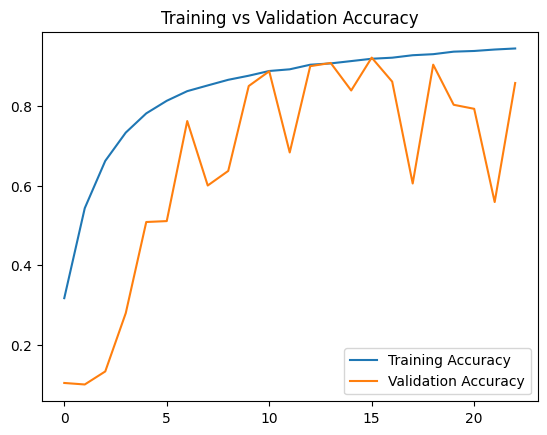

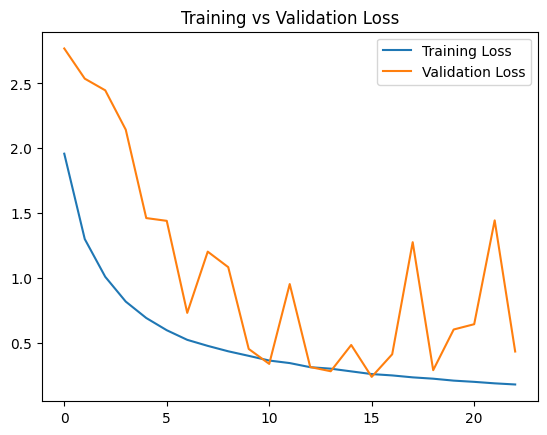

In [62]:
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

## Konversi Model

In [64]:
# SavedModel
model.export('saved_model/')

Saved artifact at 'saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_1011')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  135329115399248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135329115400976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135329115400400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135329115400208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135331548756304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135331548754000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135329115398864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135329115399056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135331548754960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135331549186384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135331549184

In [65]:
# TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model/')
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

In [66]:
# TFJS
!pip install tensorflowjs

import tensorflowjs as tfjs

tfjs.converters.save_keras_model(model, 'tfjs_model')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


failed to lookup keras version from the file,
    this is likely a weight only file


## Inference (Optional)

In [77]:
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import files
from PIL import Image

uploaded = files.upload()

model = tf.saved_model.load('/content/saved_model/')
infer = model.signatures['serving_default']

for img_path in uploaded.keys():
    img = Image.open(img_path).convert('RGB')
    img = img.resize((128, 128))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    input_tensor = tf.convert_to_tensor(img_array)

    predictions = infer(input_tensor)

    output_tensor = list(predictions.values())[0].numpy()

    predicted_class = class_names[np.argmax(output_tensor[0])]

    print(f"Predicted class for {img_path}: {predicted_class}")

Saving bird.jpg to bird.jpg
Predicted class for bird.jpg: bird
